<a href="https://colab.research.google.com/github/DanielVinicius2/Analise-dados-avan-ada/blob/main/Trabalho_Nota_2_(Dataset_10).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  1. Limpeza e Estruturação

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
from numpy import nan
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Download latest version
path = kagglehub.dataset_download("teajay/global-shark-attacks")

print("Path to dataset files", "/kaggle/input")

Using Colab cache for faster access to the 'global-shark-attacks' dataset.
Path to dataset files /kaggle/input


## 1.1 Carregar dataset

In [ ]:
df = pd.read_csv("/kaggle/input/global-shark-attacks/attacks.csv", encoding='latin1')

df.head()

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order,Unnamed: 22,Unnamed: 23
0,2018.06.25,25-Jun-2018,2018.0,Boating,USA,California,"Oceanside, San Diego County",Paddling,Julie Wolfe,F,...,White shark,"R. Collier, GSAF",2018.06.25-Wolfe.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.25,2018.06.25,6303.0,NaN,NaN
1,2018.06.18,18-Jun-2018,2018.0,Unprovoked,USA,Georgia,"St. Simon Island, Glynn County",Standing,Adyson McNeely,F,...,NaN,"K.McMurray, TrackingSharks.com",2018.06.18-McNeely.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.18,2018.06.18,6302.0,NaN,NaN
2,2018.06.09,09-Jun-2018,2018.0,Invalid,USA,Hawaii,"Habush, Oahu",Surfing,John Denges,M,...,NaN,"K.McMurray, TrackingSharks.com",2018.06.09-Denges.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.09,2018.06.09,6301.0,NaN,NaN
3,2018.06.08,08-Jun-2018,2018.0,Unprovoked,AUSTRALIA,New South Wales,Arrawarra Headland,Surfing,male,M,...,2 m shark,"B. Myatt, GSAF",2018.06.08-Arrawarra.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.08,2018.06.08,6300.0,NaN,NaN
4,2018.06.04,04-Jun-2018,2018.0,Provoked,MEXICO,Colima,La Ticla,Free diving,Gustavo Ramos,M,...,"Tiger shark, 3m",A .Kipper,2018.06.04-Ramos.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2018.06.04,2018.06.04,6299.0,NaN,NaN


## 1.2 Informações gerais

In [ ]:
df.shape

(25723, 24)

In [ ]:
df.info()
# Colunas Relevantes:
"""
 2   Year                    6300 non-null   float64
 3   Type                    6298 non-null   object
 4   Country                 6252 non-null   object
 5   Area                    5847 non-null   object
 6   Location                5762 non-null   object
 7   Activity                5758 non-null   object
 12  Fatal (Y/N)             5763 non-null   object
 14  Species                 3464 non-null   object

"""

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25723 entries, 0 to 25722
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Case Number             8702 non-null   object 
 1   Date                    6302 non-null   object 
 2   Year                    6300 non-null   float64
 3   Type                    6298 non-null   object 
 4   Country                 6252 non-null   object 
 5   Area                    5847 non-null   object 
 6   Location                5762 non-null   object 
 7   Activity                5758 non-null   object 
 8   Name                    6092 non-null   object 
 9   Sex                     5737 non-null   object 
 10  Age                     3471 non-null   object 
 11  Injury                  6274 non-null   object 
 12  Fatal (Y/N)             5763 non-null   object 
 13  Time                    2948 non-null   object 
 14  Species                 3464 non-null 

'\n 2   Year                    6300 non-null   float64\n 3   Type                    6298 non-null   object\n 4   Country                 6252 non-null   object\n 5   Area                    5847 non-null   object\n 6   Location                5762 non-null   object\n 7   Activity                5758 non-null   object\n 12  Fatal (Y/N)             5763 non-null   object\n 14  Species                 3464 non-null   object\n\n'

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Case Number,8702,6287,0,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,6302,5433,1957,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,6300.0,NaN,NaN,NaN,1927.272381,281.116308,0.0,1942.0,1977.0,2005.0,2018.0
Type,6298,8,Unprovoked,4595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,6252,212,USA,2229,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,5847,825,Florida,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,5762,4108,"New Smyrna Beach, Volusia County",163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Activity,5758,1532,Surfing,971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,6092,5230,male,550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,5737,6,M,5094,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.3 Identificando os tipos de variáveis

In [ ]:
tipologia = []

for col in df.columns:
    if col == "Year":
        tipologia.append("Intervalar")
    elif col == "Age":
        tipologia.append("Razão")
    elif col == "Fatal (Y/N)":
        tipologia.append("Nominal (Binária)")
    else:
        tipologia.append("Nominal")

df_tipologia = pd.DataFrame({
    "Variável": df.columns,
    "Tipologia": tipologia,
    "Tipo no Pandas (dtype)": [df[col].dtype for col in df.columns]
})

df_tipologia

,Variável,Tipologia,Tipo no Pandas (dtype)
0,Case Number,Nominal,object
1,Date,Nominal,object
2,Year,Intervalar,float64
3,Type,Nominal,object
4,Country,Nominal,object
5,Area,Nominal,object
6,Location,Nominal,object
7,Activity,Nominal,object
8,Name,Nominal,object
9,Sex,Nominal,object


# 2. Sanitização e Estatística Descritiva Inicial

## 2.1 Verificar valores ausentes

In [ ]:
(df.isnull().sum().sort_values())

,0
Case Number,17021
original order,19414
pdf,19421
Date,19421
href,19421
Case Number.1,19421
Case Number.2,19421
href formula,19422
Year,19423
Type,19425


## 2.2 Removendo colunas que não serão úteis para a análise

In [ ]:
cols_to_not_drop =['Year','Type','Country','Area','Location','Activity','Fatal (Y/N)','Species ','Age']

def delete_columns (df):
  for col in df.columns:
    if col in cols_to_not_drop:
      pass
    else:
      df = df.drop(columns=col)
  return df

In [ ]:
df = delete_columns(df)

In [ ]:
df = df.drop(df.index[6302:])
df.isnull().sum()

,0
Year,2
Type,4
Country,50
Area,455
Location,540
Activity,544
Age,2831
Fatal (Y/N),539
Species,2838


## 2.3 Corrigindo tipos de dados, identificando e tratando valores ausentes, detectando e tratando duplicatas

In [ ]:
# Padronizar nomes das colunas (remove espaços extras)
df.columns = df.columns.str.strip()

# Padronizar valores vazios comuns para NaN
df = df.replace(["", " ", "NA", "N/A", "null", "None"], np.nan)

# Remover espaços extras em colunas texto
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Corrigir tipos de dados (converter strings para numéricos)
if "Year" in df.columns:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

if "Age" in df.columns:
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Tratamento de valores ausentes
if "Year" in df.columns:
    df = df.dropna(subset=["Year"])

# imputar com mediana (mais robusta que média)
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

# Fatal: preencher nulos como Unknown
if "Fatal (Y/N)" in df.columns:
    df["Fatal (Y/N)"] = df["Fatal (Y/N)"].fillna("Unknown")

# Species: preencher nulos como Unknown
if "Species" in df.columns:
    df["Species"] = df["Species"].fillna("Unknown")

# Padronizar texto das colunas categóricas (evita categorias duplicadas)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip().str.title()

# Correções específicas em categorias (dataset Shark Attacks)
if "Fatal (Y/N)" in df.columns:
    df["Fatal (Y/N)"] = df["Fatal (Y/N)"].replace({
        " N": "N", "N ": "N",
        " Y": "Y", "Y ": "Y",
        "y": "Y", "n": "N",
        "2017": "Unknown",
        "M": "Unknown"
    })

# Corrigir "Nan" que virou string na Species
if "Species" in df.columns:
    df["Species"] = df["Species"].replace("Nan", "Unknown")

# Detectar e remover duplicatas
df = df.drop_duplicates()

# 3. Detectando e Tratando Outliers (IQR)

In [ ]:
colunas_numericas = df.select_dtypes(include=["int64", "float64"]).columns

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    print(f"\nColuna: {col}")
    print(f"Limite inferior: {limite_inferior:.2f}")
    print(f"Limite superior: {limite_superior:.2f}")
    print(f"Quantidade de outliers detectados: {len(outliers)}")


Coluna: Year
Limite inferior: 1847.50
Limite superior: 2099.50
Quantidade de outliers detectados: 259

Coluna: Age
Limite inferior: 17.50
Limite superior: 29.50
Quantidade de outliers detectados: 2083


# 4. Entrega do DataFrame limpo

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6252 entries, 0 to 6301
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         6252 non-null   float64
 1   Type         6252 non-null   object 
 2   Country      6252 non-null   object 
 3   Area         6252 non-null   object 
 4   Location     6252 non-null   object 
 5   Activity     6252 non-null   object 
 6   Age          6252 non-null   float64
 7   Fatal (Y/N)  6252 non-null   object 
 8   Species      6252 non-null   object 
dtypes: float64(2), object(7)
memory usage: 488.4+ KB


In [ ]:
df.isnull().sum().sort_values(ascending=False).head(15)

,0
Year,0
Type,0
Country,0
Area,0
Location,0
Activity,0
Age,0
Fatal (Y/N),0
Species,0


In [ ]:
# =====================================================
# RELATÓRIO TÉCNICO - LIMPEZA E ESTRUTURAÇÃO (ENTREGA 1)
# =====================================================
# Durante a etapa de limpeza e preparação do dataset attacks.csv, foram realizadas
# algumas correções para garantir que os dados ficassem mais consistentes e prontos
# para as análises estatísticas e gráficas.

# 1) Seleção das colunas principais
# Foram mantidas apenas as variáveis mais importantes para a análise:
# Year, Type, Country, Area, Location, Activity, Fatal (Y/N), Species e Age.
# Isso foi feito para remover colunas que não seriam úteis e evitar excesso de informações.

# 2) Padronização dos dados
# Foi feita uma padronização geral dos textos:
# - remoção de espaços extras nas colunas e nos valores
# - transformação dos textos para um formato mais uniforme (Title Case),
#   evitando que a mesma categoria aparecesse escrita de formas diferentes.

# 3) Tratamento de valores ausentes
# Para lidar com dados faltantes:
# - em Year, linhas sem ano foram removidas, já que essa variável é essencial para análise temporal
# - em Age, os valores ausentes foram preenchidos pela mediana, pois é uma medida mais resistente a extremos
# - em Fatal (Y/N) e Species, valores ausentes foram preenchidos com "Unknown"

# 4) Correção de inconsistências
# Algumas colunas apresentavam valores inconsistentes ou digitados incorretamente, então foram corrigidas:
# - Fatal (Y/N): corrigidos casos como " N", "N ", "y", e outros valores estranhos para o padrão Y/N/Unknown
# - Species: corrigido o texto "Nan" para "Unknown"
# - Type: valores como "Invalid" e "Questionable" foram agrupados como "Unknown"

# 5) Remoção de duplicatas
# Registros duplicados foram identificados e removidos para evitar repetição de casos
# e distorção nos resultados estatísticos.

# 6) Correção de tipos de dados
# As variáveis numéricas foram convertidas corretamente:
# - Year foi convertido para numérico
# - Age foi convertido para numérico

# 7) Identificação de outliers
# Foi aplicado o método IQR (Intervalo Interquartílico) para detectar valores extremos
# nas colunas numéricas, registrando os limites inferior e superior e a quantidade de outliers encontrados.

# 2. Análise Estatística, Probabilística e Visual

# 5. Análise Univariada (Medidas de Tendência Central, Dispersão e Forma)

## 5.1 Tendência Central (Média, Mediana, Moda)

In [ ]:
print("MÉDIA Age:", df["Age"].mean())
print("MEDIANA Age:", df["Age"].median())
print("MODA Age:", df["Age"].mode()[0])

print("\nMÉDIA Year:", df["Year"].mean())
print("MEDIANA Year:", df["Year"].median())
print("MODA Year:", df["Year"].mode()[0])

# A mediana é a melhor medida para representar o centro principalmente da variável Age,
# pois a idade pode ter valores extremos (outliers) que distorcem a média.

MÉDIA Age: 25.816698656429942
MEDIANA Age: 24.0
MODA Age: 24.0

MÉDIA Year: 1927.3523672424824
MEDIANA Year: 1977.0
MODA Year: 2015.0


## 5.2 Dispersão (Variância, Desvio Padrão e Amplitude)**negrito**

In [ ]:
print("VARIÂNCIA Age:", df["Age"].var())
print("DESVIO PADRÃO Age:", df["Age"].std())
print("AMPLITUDE Age:", df["Age"].max() - df["Age"].min())

print("\nVARIÂNCIA Year:", df["Year"].var())
print("DESVIO PADRÃO Year:", df["Year"].std())
print("AMPLITUDE Year:", df["Year"].max() - df["Year"].min())

VARIÂNCIA Age: 106.98127286199008
DESVIO PADRÃO Age: 10.343175182795179
AMPLITUDE Age: 86.0

VARIÂNCIA Year: 79014.67073027739
DESVIO PADRÃO Year: 281.09548329753966
AMPLITUDE Year: 2018.0


## 5.3 Forma (Assimetria e Curtose)

In [ ]:
print("ASSIMETRIA Age:", df["Age"].skew())
print("CURTOSE Age:", df["Age"].kurtosis())

print("\nASSIMETRIA Year:", df["Year"].skew())
print("CURTOSE Year:", df["Year"].kurtosis())

ASSIMETRIA Age: 1.777883924356678
CURTOSE Age: 4.506336532964466

ASSIMETRIA Year: -6.508363174579852
CURTOSE Year: 41.6484009835817


## 5.4 Visualização (Histogramas e Boxplots)

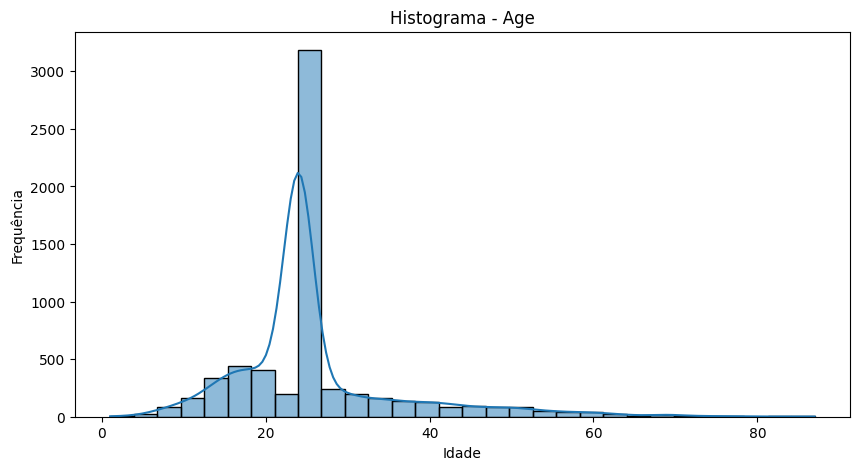

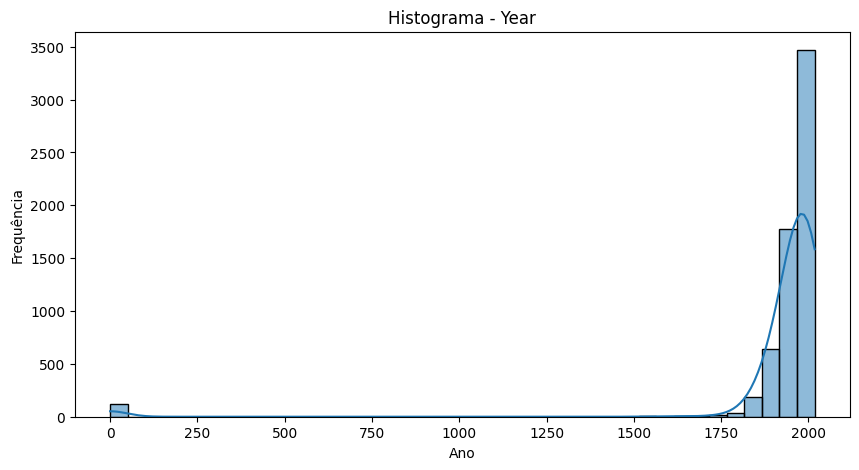

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Histograma - Age")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df["Year"], bins=40, kde=True)
plt.title("Histograma - Year")
plt.xlabel("Ano")
plt.ylabel("Frequência")
plt.show()

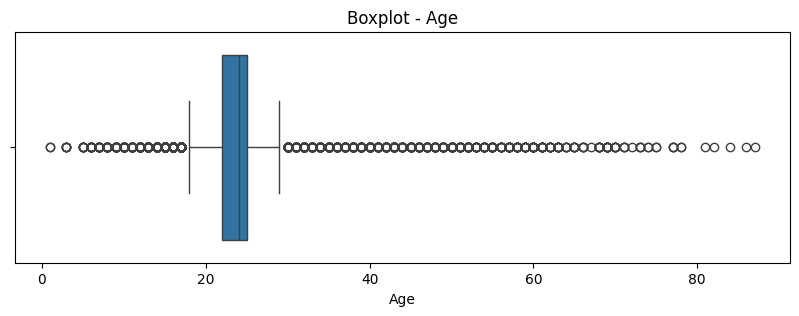

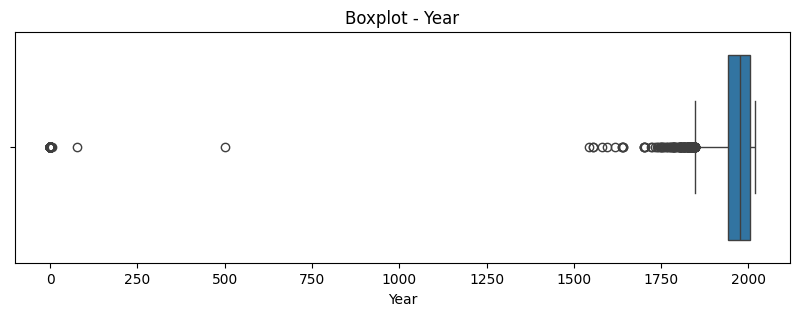

In [ ]:
plt.figure(figsize=(10,3))
sns.boxplot(x=df["Age"])
plt.title("Boxplot - Age")
plt.show()

plt.figure(figsize=(10,3))
sns.boxplot(x=df["Year"])
plt.title("Boxplot - Year")
plt.show()

# 6. Probabilidade em Análise de Dados

## 6.1 Probabilidade simples (evento de interesse)

In [ ]:
prob_fatal = (df["Fatal (Y/N)"] == "Y").mean() * 100
prob_nao_fatal = (df["Fatal (Y/N)"] == "N").mean() * 100
prob_unknown = (df["Fatal (Y/N)"] == "Unknown").mean() * 100

print(f"Probabilidade de ser Fatal: {prob_fatal:.2f}%")
print(f"Probabilidade de não ser Fatal: {prob_nao_fatal:.2f}%")
print(f"Desconhecidos: {prob_unknown:.2f}%")

Probabilidade de ser Fatal: 21.99%
Probabilidade de não ser Fatal: 68.27%
Desconhecidos: 1.14%


## 6.2 Probabilidade condicional


Probabilidade do ataque ser fatal dado que o país é USA

In [ ]:
pais = "Usa"
df_pais = df[df["Country"] == pais]

prob_fatal_pais = (df_pais["Fatal (Y/N)"] == "Y").mean() * 100

print(f"Probabilidade do ataque ser fatal no país {pais}: {prob_fatal_pais:.2f}%")

Probabilidade do ataque ser fatal no país Usa: 8.35%


Probabilidade do ataque ser fatal dado que o tipo é Unprovoked (Não Provocado)

In [ ]:
tipo = "Unprovoked"
df_tipo = df[df["Type"] == tipo]

prob_fatal_tipo = (df_tipo["Fatal (Y/N)"] == "Y").mean() * 100

print(f"Probabilidade do ataque ser fatal do tipo {tipo} é: {prob_fatal_tipo:.2f}%")

Probabilidade do ataque ser fatal do tipo Unprovoked é: 25.66%


Probabilidade do ataque ser em um dos países do top 5 com mais ataques

In [ ]:
top5_paises = df["Country"].value_counts().head(5)
total = len(df)

print("Top 5 países com mais ataques:\n")
print(top5_paises)

print("\nProbabilidade (%) de um ataque ocorrer em cada país do Top 5:\n")

for pais, qtd in top5_paises.items():
    prob = (qtd / total) * 100
    print(f"{pais}: {prob:.2f}%")

Top 5 países com mais ataques:

Country
Usa                 2215
Australia           1329
South Africa         577
Papua New Guinea     134
New Zealand          127
Name: count, dtype: int64

Probabilidade (%) de um ataque ocorrer em cada país do Top 5:

Usa: 35.43%
Australia: 21.26%
South Africa: 9.23%
Papua New Guinea: 2.14%
New Zealand: 2.03%


## 7. Análise Bivariada (Conexões e Correlações)

### 7.1 Correlação (Pearson e Spearman)

In [ ]:
# Calculando o coeficiente de correlação de Pearson entre Idade e Ano
pearson_corr_age_year = df["Age"].corr(df["Year"], method="pearson")
print(f"Correlação de Pearson entre Idade e Ano: {pearson_corr_age_year:.2f}")

# Calculando o coeficiente de correlação de Spearman entre Idade e Ano
spearman_corr_age_year = df["Age"].corr(df["Year"], method="spearman")
print(f"Correlação de Spearman entre Idade e Ano: {spearman_corr_age_year:.2f}")

# Análise:
# - Uma correlação próxima de 0 indica pouca ou nenhuma relação linear/monotônica entre as variáveis.
# - Pearson mede a relação linear, enquanto Spearman mede a relação monotônica (tendência, mesmo que não linear).

Correlação de Pearson entre Idade e Ano: 0.05
Correlação de Spearman entre Idade e Ano: 0.11


### 7.2 Associação: Variável Categórica vs. Numérica

Média de Idade por Desfecho (Fatal ou Não Fatal):
   Fatal (Y/N)        Age
0           N  25.949157
1         Nan  26.176580
2     Unknown  23.704225
3           Y  25.373818


/tmp/ipykernel_11566/4087953952.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Fatal (Y/N)", y="Age", data=df, palette="viridis")


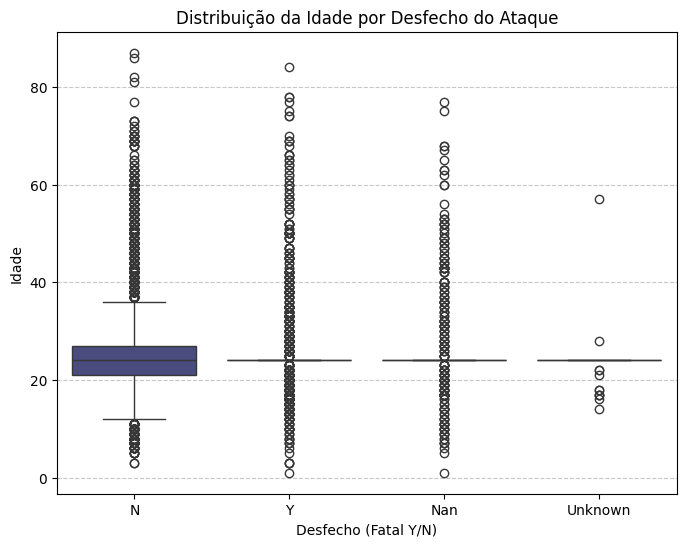

In [ ]:
# Como a variável categórica 'Fatal (Y/N)' influencia a 'Age'

# Média de idade para ataques fatais e não fatais
mean_age_fatal = df.groupby("Fatal (Y/N)")["Age"].mean().reset_index()
print("Média de Idade por Desfecho (Fatal ou Não Fatal):\n", mean_age_fatal)

# Visualização da distribuição de Age por Fatal (Y/N) usando boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x="Fatal (Y/N)", y="Age", data=df, palette="viridis")
plt.title("Distribuição da Idade por Desfecho do Ataque")
plt.xlabel("Desfecho (Fatal Y/N)")
plt.ylabel("Idade")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_11566/4116114239.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Type", y="Age", data=df, palette="plasma")


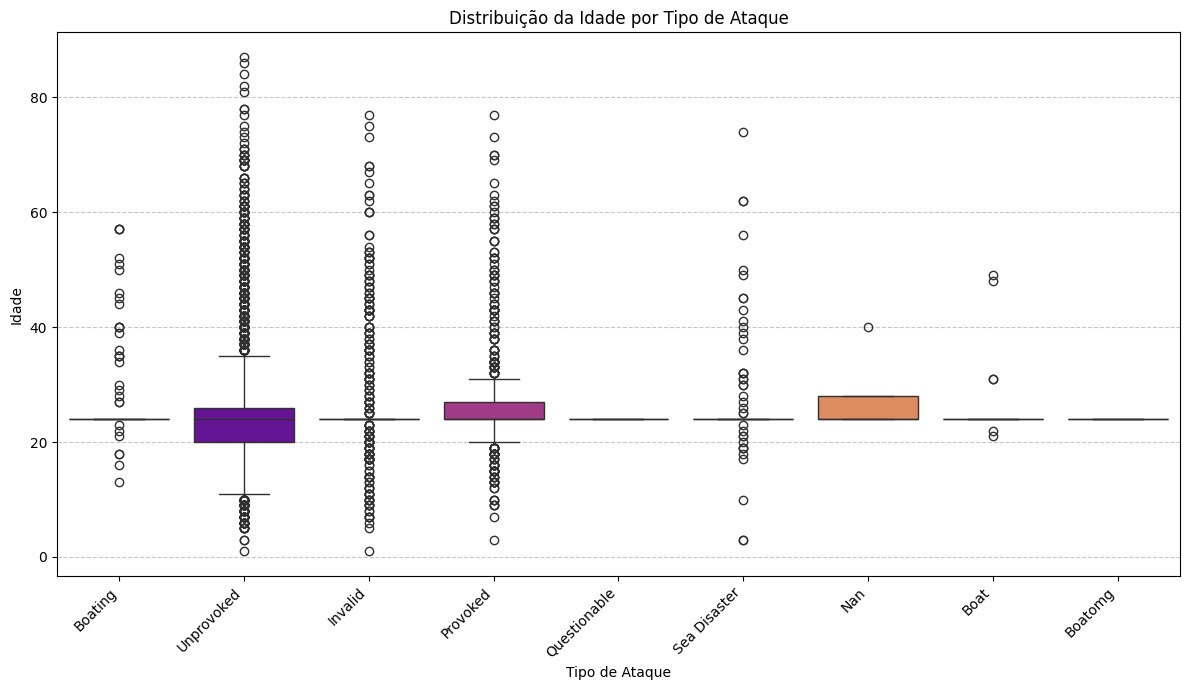

In [ ]:
# Como a variável categórica 'Type' influencia a 'Age'

# Visualização da distribuição de Age por Type usando boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(x="Type", y="Age", data=df, palette="plasma")
plt.title("Distribuição da Idade por Tipo de Ataque")
plt.xlabel("Tipo de Ataque")
plt.ylabel("Idade")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Análise:
# - Observe se há diferenças significativas nas medianas e na dispersão da idade entre os diferentes tipos de ataques ou desfechos.
# - Outliers em boxplots podem indicar idades incomuns para certos tipos de eventos.

## 8. Visualização de Dados e Tipologia de Gráficos

A seguir, apresento gráficos para diferentes objetivos de análise, aplicando princípios de percepção visual para clareza e impacto.

### 8.1 Comparação: Ataques por País (Top 10)

/tmp/ipykernel_11566/3408662438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='crest')


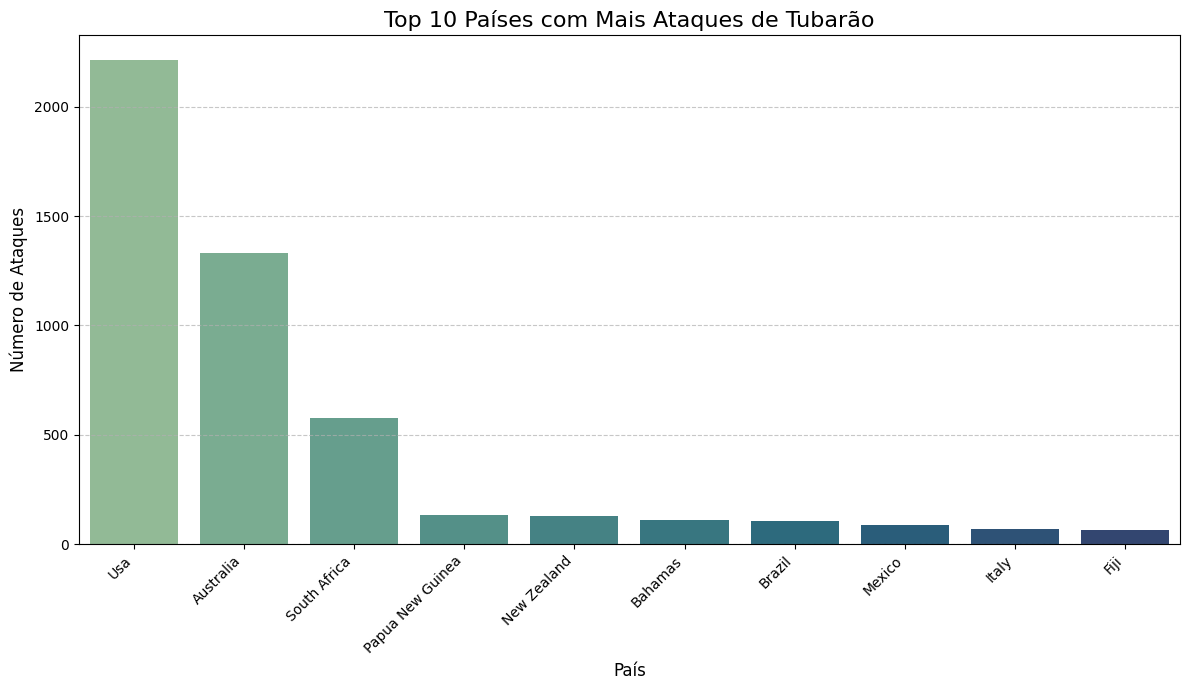

In [ ]:
# Comparação: Top 10 países com mais ataques
top_10_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='crest')
plt.title('Top 10 Países com Mais Ataques de Tubarão', fontsize=16)
plt.xlabel('País', fontsize=12)
plt.ylabel('Número de Ataques', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Princípios de Percepção Visual:
# - **Data-Ink Ratio**: Barras proporcionais aos valores, sem elementos desnecessários.
# - **Gestalt - Proximidade**: Barras do mesmo país estão próximas, formando um grupo visual.
# - **Hierarquia**: Título claro e rótulos bem definidos direcionam o olhar para a informação principal.

### 8.2 Distribuição: Ataques ao Longo do Tempo (Anos)

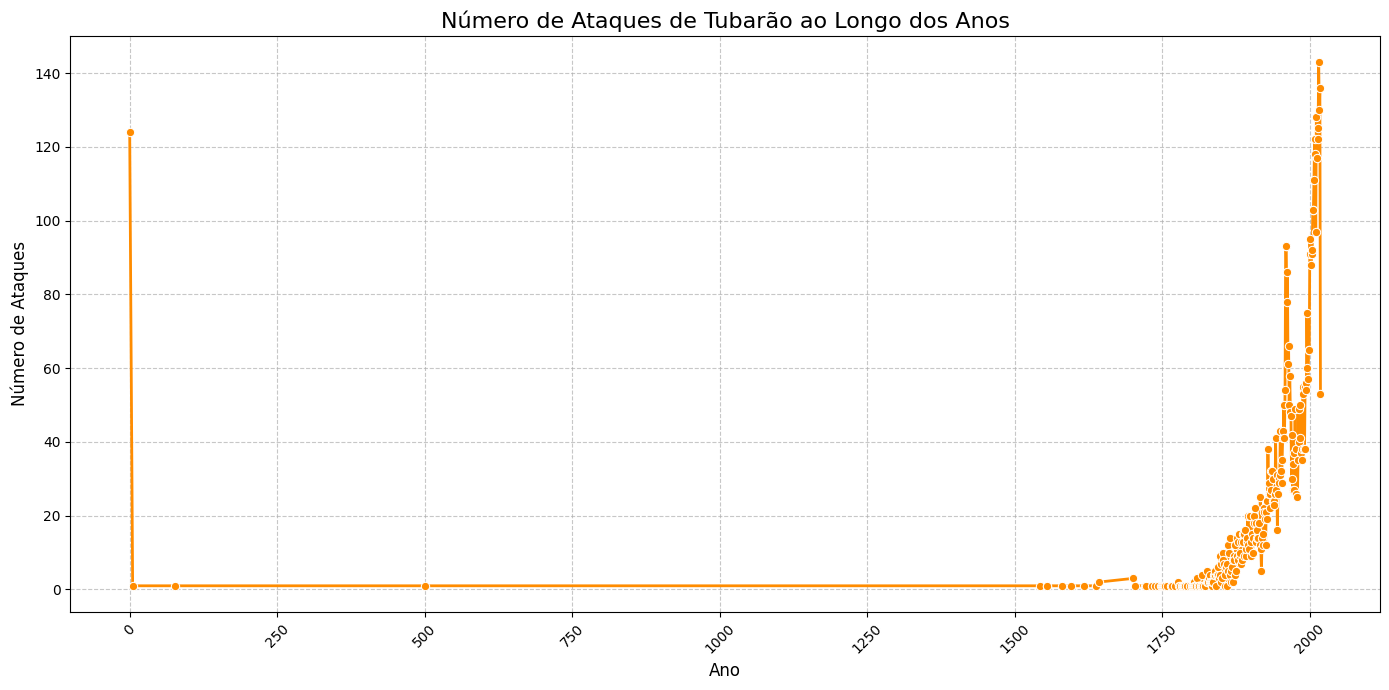

In [ ]:
# Distribuição: Número de ataques por ano
attacks_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x=attacks_per_year.index, y=attacks_per_year.values, marker='o', color='darkorange', linewidth=2)
plt.title('Número de Ataques de Tubarão ao Longo dos Anos', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número de Ataques', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Princípios de Percepção Visual:
# - **Data-Ink Ratio**: Linhas e pontos são o foco, sem poluição visual.
# - **Gestalt - Continuidade**: A linha conecta os pontos, mostrando a tendência temporal.
# - **Hierarquia**: Título e eixos claros para facilitar a compreensão da evolução dos ataques.

### 8.3 Relação: Proporção de Ataques Fatais por Tipo

/tmp/ipykernel_11566/3381416694.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fatal_proportion.index, y=fatal_proportion.values, palette='rocket')


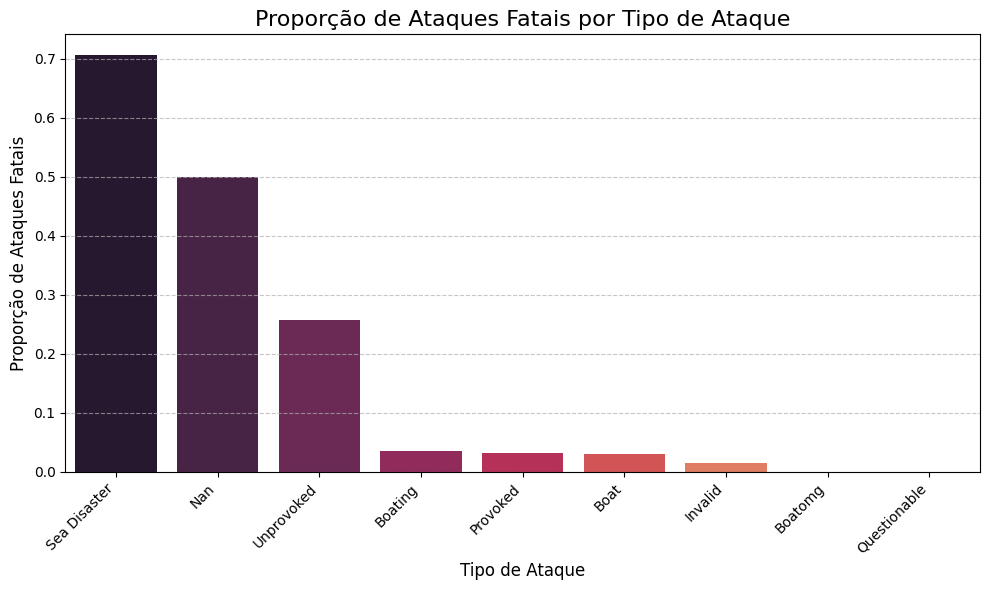

In [ ]:
# Relação: Proporção de ataques fatais por tipo de ataque
fatal_by_type = df.groupby('Type')['Fatal (Y/N)'].value_counts(normalize=True).unstack().fillna(0)

# Selecionar apenas a proporção de 'Y' (Fatal) e ordenar
fatal_proportion = fatal_by_type['Y'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=fatal_proportion.index, y=fatal_proportion.values, palette='rocket')
plt.title('Proporção de Ataques Fatais por Tipo de Ataque', fontsize=16)
plt.xlabel('Tipo de Ataque', fontsize=12)
plt.ylabel('Proporção de Ataques Fatais', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Princípios de Percepção Visual:
# - **Data-Ink Ratio**: Barras diretas para a proporção, com cores contrastantes.
# - **Gestalt - Similaridade**: Barras de proporção similar são visualmente agrupadas.
# - **Hierarquia**: O título e os rótulos de eixos são legíveis e a ordem decrescente facilita a comparação rápida.

# Trabalho Realizado por:
- Daniel Vinicius
- Saulo Pietro
- Arthur de Holanda